# ToyCar: normal vs anomalous geometry (spectrogram + VQ latents)

Loads **ToyCar** DCASE2020 Task 2 **test** clips and the **Stage 1** VQ-VAE checkpoint (fine + coarse codebooks). The test set is **stratified** by `machine_id` and label (normal vs anomalous).

We compare:
- **Spectrogram space**: mean log-mel per group and **per-bin** difference maps (anomaly mean minus normal mean) for each machine.
- **Two latent spaces** (quantized encoder outputs): **fine** `q_fine` and **coarse** `q_coarse` — spatial maps of $\|\mathbb{E}[q\mid\text{anom}]-\mathbb{E}[q\mid\text{norm}]\|_2$.

## 1. Paths and imports

In [ ]:
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from torch.utils.data import DataLoader


def find_project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / "src" / "data" / "dataset.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Could not find project root (src/data/dataset.py). Run from repo or notebooks/ToyCar.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CKPT_DIR = PROJECT_ROOT / "checkpoints"
STAGE1_CKPT = (
    CKPT_DIR
    / "stage1"
    / "ToyCar+ToyConveyor+fan+pump+slider+valve"
    / "h128_e128_kc512_kf1024_stage1_all_best.pt"
)

DATA_PATH = Path("/mnt/ssd/LaCie/dcase2020-task2-dev-dataset")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset")
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "data" / "dcase2020-task2-dev-dataset"
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "dataset" / "dcase2020_task2_dev_dataset"
if not DATA_PATH.exists():
    DATA_PATH = Path("../../data/dcase2020-task2-dev-dataset").resolve()

MACHINE_TYPE = "ToyCar"
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH} (exists={DATA_PATH.exists()})")
print(f"STAGE1_CKPT: {STAGE1_CKPT} (exists={STAGE1_CKPT.exists()})")
print(f"Device: {DEVICE}")

PROJECT_ROOT: /home/lucash/Documents/NTUST/Research/papers/semantic-communication-networks/audDSR
DATA_PATH: /mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset (exists=True)
STAGE1_CKPT: /home/lucash/Documents/NTUST/Research/papers/semantic-communication-networks/audDSR/checkpoints/stage1/ToyCar+ToyConveyor+fan+pump+slider+valve/h128_e128_kc512_kf1024_stage1_all_best.pt (exists=True)
Device: cuda


## 2. Load Stage 1 VQ-VAE and ToyCar test set

`DCASE2020Task2TestDataset` returns standardized log-mel `(1, n_mels, T)` with `target_T` aligned to training (320).

In [3]:
from src.data.dataset import DCASE2020Task2TestDataset
from src.models.vq_vae.autoencoders import VQ_VAE_2Layer
from src.utils.checkpoint_compat import migrate_vq_vae_state_dict

if not STAGE1_CKPT.exists():
    raise FileNotFoundError(f"Missing checkpoint: {STAGE1_CKPT}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing dataset root: {DATA_PATH}")

ckpt = torch.load(STAGE1_CKPT, map_location="cpu", weights_only=True)

n_mels, T = 128, 320
test_ds = DCASE2020Task2TestDataset(
    root=str(DATA_PATH),
    machine_type=MACHINE_TYPE,
    target_T=T,
)

num_embeddings_coarse = ckpt["num_embeddings_coarse"]
num_embeddings_fine = ckpt["num_embeddings_fine"]
embedding_dim_coarse = ckpt["embedding_dim_coarse"]
embedding_dim_fine = ckpt["embedding_dim_fine"]
hidden_channels_coarse = ckpt["hidden_channels_coarse"]
hidden_channels_fine = ckpt["hidden_channels_fine"]
num_residual_layers = ckpt["num_residual_layers"]

vq_vae = VQ_VAE_2Layer(
    hidden_channels=(hidden_channels_coarse, hidden_channels_fine),
    num_residual_layers=num_residual_layers,
    num_embeddings=(num_embeddings_coarse, num_embeddings_fine),
    embedding_dim=(embedding_dim_coarse, embedding_dim_fine),
    commitment_cost=0.25,
    decay=float(ckpt.get("decay", 0.99)),
)
state = dict(ckpt["model_state_dict"])
migrate_vq_vae_state_dict(state)
vq_vae.load_state_dict(state)
vq_vae = vq_vae.eval().to(DEVICE)

print(f"Test clips: {len(test_ds)} | n_mels={n_mels}, T={T}")
print(f"Fine grid q_fine: H={n_mels // 4}, W={T // 4}")
print(f"Coarse grid q_coarse: H={n_mels // 8}, W={T // 8}")

DCASE2020Task2TestDataset: ToyCar | 2459 clips | IDs: ['id_01', 'id_02', 'id_03', 'id_04']
Test clips: 2459 | n_mels=128, T=320
Fine grid q_fine: H=32, W=80
Coarse grid q_coarse: H=16, W=40


## 3. Stratify by `machine_id` and label

In [4]:
grouped = defaultdict(lambda: {0: [], 1: []})
for idx in range(len(test_ds)):
    spec, label, machine_id = test_ds[idx]
    if spec.dim() == 3:
        spec = spec.unsqueeze(0)
    grouped[machine_id][int(label)].append((spec, idx))

print("Counts (normal / anomalous):")
for mid in sorted(grouped.keys()):
    n0, n1 = len(grouped[mid][0]), len(grouped[mid][1])
    print(f"  {mid}: normal={n0}, anomalous={n1}")

Counts (normal / anomalous):
  id_01: normal=350, anomalous=264
  id_02: normal=350, anomalous=265
  id_03: normal=350, anomalous=265
  id_04: normal=350, anomalous=265


In [ ]:
# One example clip per machine_id: normal vs anomalous (standardized log-mel from the test set)
rows = []
for mid in sorted(grouped.keys()):
    if not grouped[mid][0] or not grouped[mid][1]:
        print(f"Skip {mid}: need both labels for side-by-side examples.")
        continue
    s_n, idx_n = grouped[mid][0][0]
    s_a, idx_a = grouped[mid][1][0]
    x_n = s_n.float().squeeze().cpu().numpy()
    x_a = s_a.float().squeeze().cpu().numpy()
    rows.append((mid, idx_n, idx_a, x_n, x_a))

if not rows:
    print("No machine_id with both labels; nothing to plot.")
else:
    fig, axes = plt.subplots(len(rows), 2, figsize=(10, 2.6 * len(rows)), squeeze=False)
    for r, (mid, idx_n, idx_a, x_n, x_a) in enumerate(rows):
        lo = float(min(x_n.min(), x_a.min()))
        hi = float(max(x_n.max(), x_a.max()))
        for ax, x, title in zip(
            axes[r],
            (x_n, x_a),
            (
                f"{mid} — one normal (idx={idx_n})",
                f"{mid} — one anomalous (idx={idx_a})",
            ),
        ):
            im = ax.imshow(x, aspect="auto", origin="lower", cmap="magma", vmin=lo, vmax=hi)
            ax.set_title(title)
            ax.set_xlabel("time frame")
            ax.set_ylabel("mel bin")
            plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

## 4. Spectrogram: mean per group and per-bin difference (anom $-$ normal)

For each `machine_id` with both classes, we plot mean spectrograms and the **pixel-wise** difference of means.

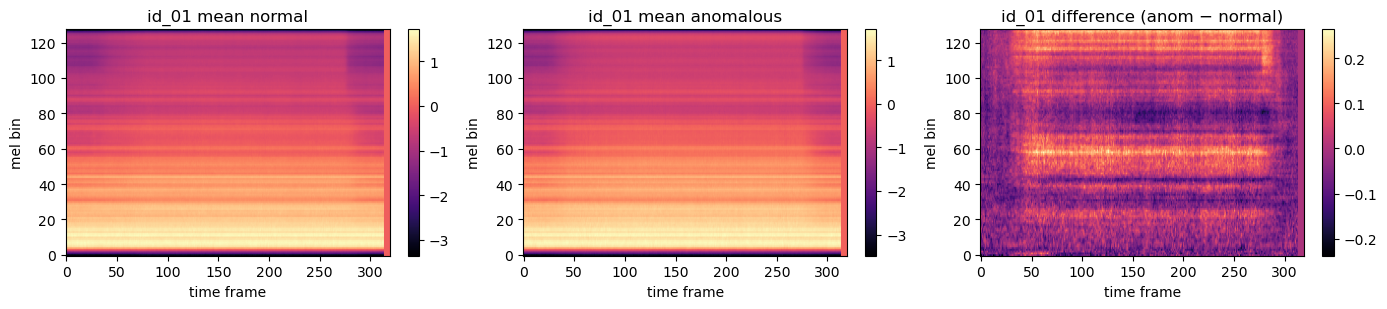

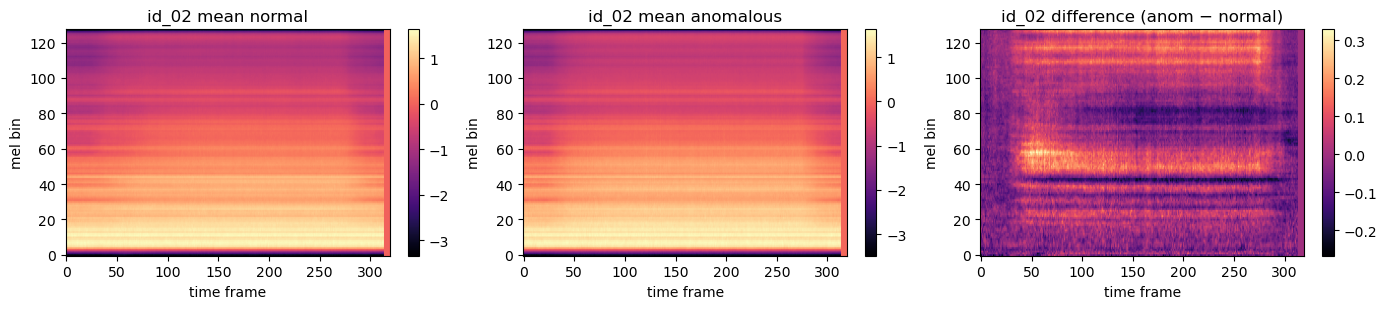

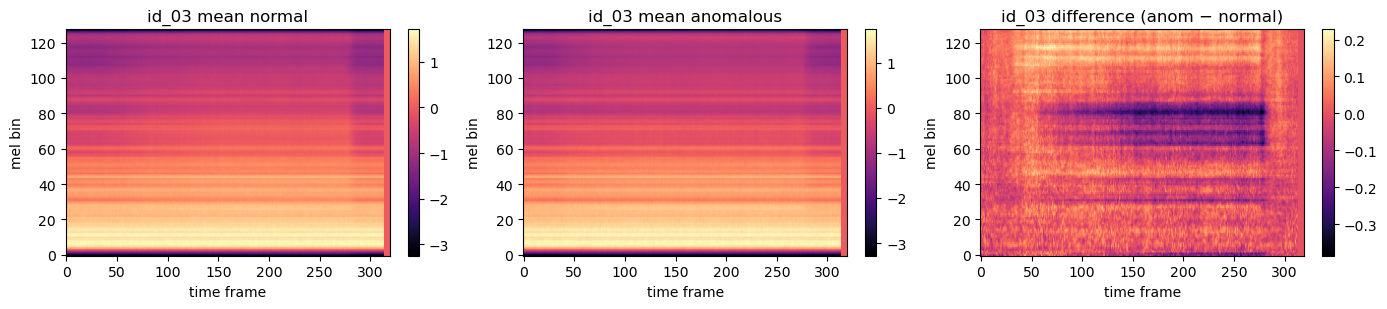

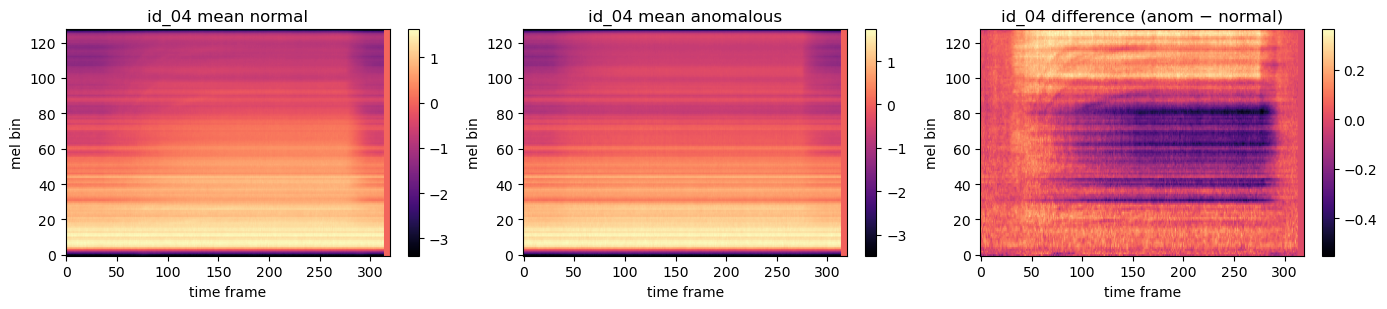

In [5]:
def mean_spec(spec_list):
    if not spec_list:
        return None
    stacked = torch.cat([s[0] for s in spec_list], dim=0)
    return stacked.mean(dim=0).squeeze(0).cpu().numpy()  # (n_mels, T)


fig_h = max(2.5, 1.2 * len(grouped))
for mid in sorted(grouped.keys()):
    norm = mean_spec(grouped[mid][0])
    anom = mean_spec(grouped[mid][1])
    if norm is None or anom is None:
        print(f"Skip {mid}: need both normal and anomalous clips.")
        continue
    diff = anom - norm
    vmax = float(max(abs(diff.min()), abs(diff.max()), 1e-6))
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
    for ax, z, title in zip(
        axes,
        [norm, anom, diff],
        [f"{mid} mean normal", f"{mid} mean anomalous", f"{mid} difference (anom − normal)"],
    ):
        if title.endswith("difference"):
            im = ax.imshow(z, aspect="auto", origin="lower", cmap="coolwarm", norm=TwoSlopeNorm(0.0, vmin=-vmax, vmax=vmax))
            plt.colorbar(im, ax=ax, fraction=0.046)
        else:
            im = ax.imshow(z, aspect="auto", origin="lower", cmap="magma")
            plt.colorbar(im, ax=ax, fraction=0.046)
        ax.set_xlabel("time frame")
        ax.set_ylabel("mel bin")
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

**Pooled ToyCar view** — mean absolute difference map aggregated over all machine IDs (still per-bin):

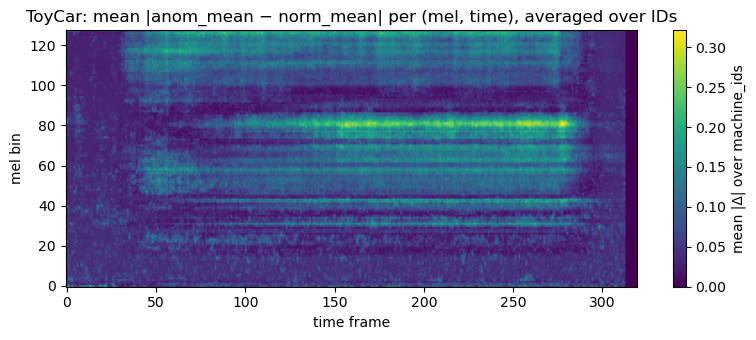

In [6]:
pairs = []
for mid in grouped:
    norm = mean_spec(grouped[mid][0])
    anom = mean_spec(grouped[mid][1])
    if norm is None or anom is None:
        continue
    pairs.append(anom - norm)
if pairs:
    stacked_diff = np.stack(pairs, axis=0)
    mean_abs = np.mean(np.abs(stacked_diff), axis=0)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    im = ax.imshow(mean_abs, aspect="auto", origin="lower", cmap="viridis")
    plt.colorbar(im, ax=ax, label="mean |Δ| over machine_ids")
    ax.set_title("ToyCar: mean |anom_mean − norm_mean| per (mel, time), averaged over IDs")
    ax.set_xlabel("time frame")
    ax.set_ylabel("mel bin")
    plt.tight_layout()
    plt.show()
else:
    print("No machine_id with both labels; skip pooled map.")

## 5. Encode full test set: `q_fine`, `q_coarse` (quantized latents)

Batched forward through `vq_vae.encode`.

In [7]:
loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

qf_list, qc_list, labels_list, mids_list = [], [], [], []
with torch.no_grad():
    for batch in loader:
        x, y, mids = batch
        x = x.to(DEVICE)
        q_fine, q_coarse = vq_vae.encode(x)
        qf_list.append(q_fine.cpu())
        qc_list.append(q_coarse.cpu())
        labels_list.append(y)
        mids_list.extend(mids if isinstance(mids, list) else list(mids))

Q_fine = torch.cat(qf_list, dim=0)
Q_coarse = torch.cat(qc_list, dim=0)
labels_t = torch.cat(labels_list, dim=0).long()
print("Q_fine:", tuple(Q_fine.shape), "Q_coarse:", tuple(Q_coarse.shape))

idx_by_mid_lab = defaultdict(lambda: {0: [], 1: []})
for i, mid in enumerate(mids_list):
    lab = int(labels_t[i].item())
    idx_by_mid_lab[mid][lab].append(i)

Q_fine: (2459, 128, 32, 80) Q_coarse: (2459, 128, 16, 40)


## 6. Latent space maps: $\|\mathbb{E}[q\mid \text{anom}] - \mathbb{E}[q\mid \text{norm}]\|_2$ per spatial bin

For each **fine** and **coarse** grid location we take the L2 norm across the embedding channel dimension.

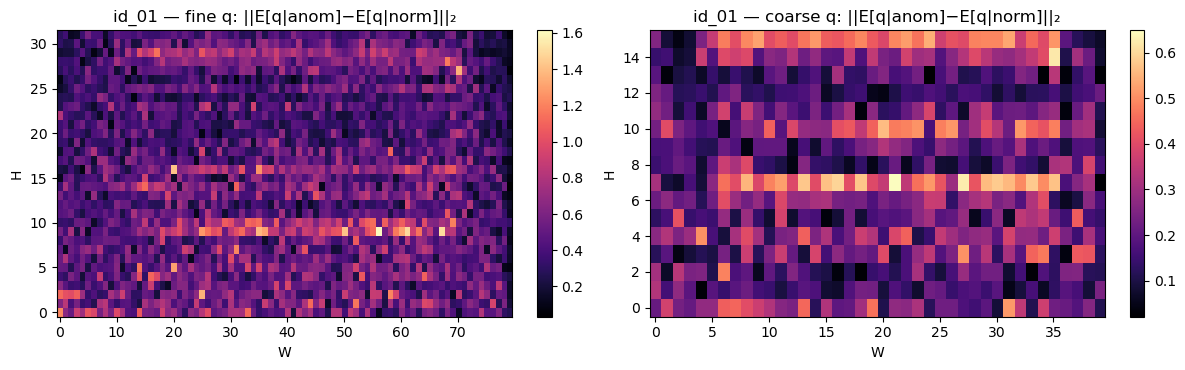

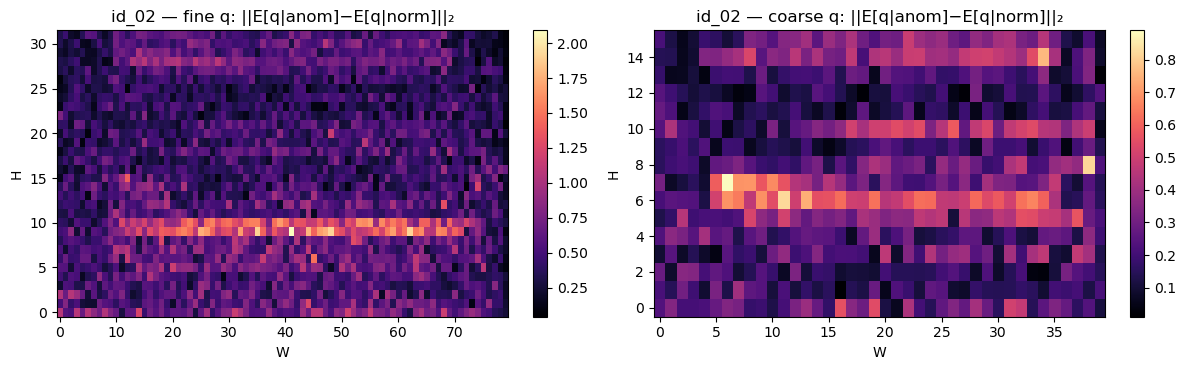

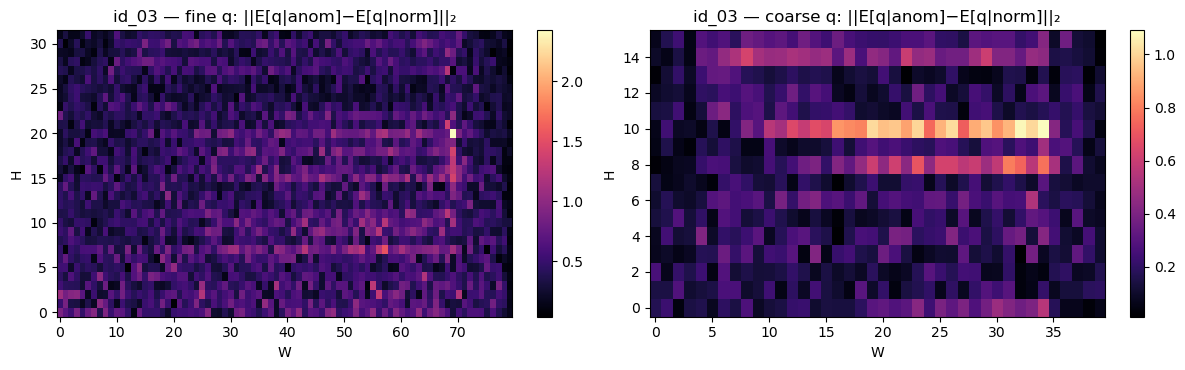

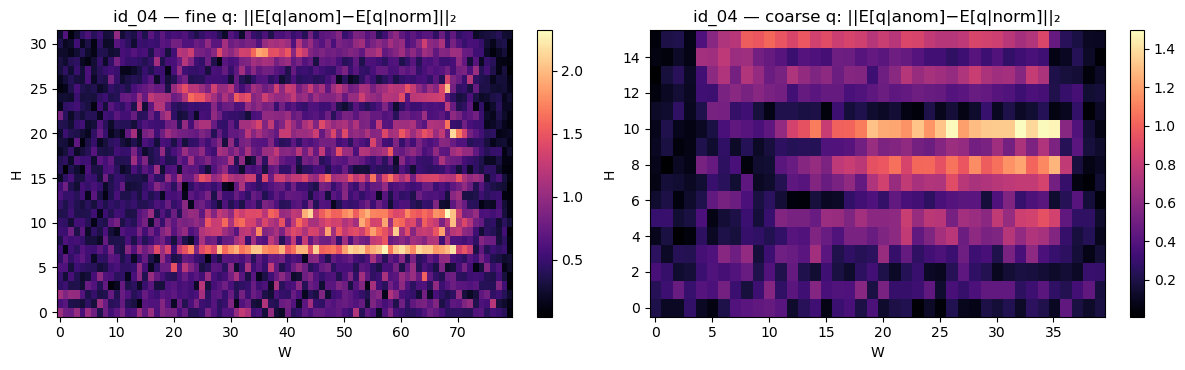

In [8]:
def mean_latent(indices, Q):
    if not indices:
        return None
    return Q[indices].mean(dim=0)  # (C, H, W)


def diff_map_l2(a, b):
    if a is None or b is None:
        return None
    return (a - b).pow(2).sum(dim=0).sqrt().numpy()  # (H, W)


for mid in sorted(idx_by_mid_lab.keys()):
    i0 = idx_by_mid_lab[mid][0]
    i1 = idx_by_mid_lab[mid][1]
    if not i0 or not i1:
        print(f"Skip {mid}: need both labels in encoded batch.")
        continue
    mf0, mf1 = mean_latent(i0, Q_fine), mean_latent(i1, Q_fine)
    mc0, mc1 = mean_latent(i0, Q_coarse), mean_latent(i1, Q_coarse)
    df = diff_map_l2(mf1, mf0)
    dc = diff_map_l2(mc1, mc0)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    im0 = axes[0].imshow(df, aspect="auto", origin="lower", cmap="magma")
    axes[0].set_title(f"{mid} — fine q: ||E[q|anom]−E[q|norm]||₂")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    im1 = axes[1].imshow(dc, aspect="auto", origin="lower", cmap="magma")
    axes[1].set_title(f"{mid} — coarse q: ||E[q|anom]−E[q|norm]||₂")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    for ax in axes:
        ax.set_xlabel("W")
        ax.set_ylabel("H")
    plt.tight_layout()
    plt.show()